Đang đọc dữ liệu (1 triệu dòng)...
Kích thước dữ liệu: (1010826, 10)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010826 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB
None


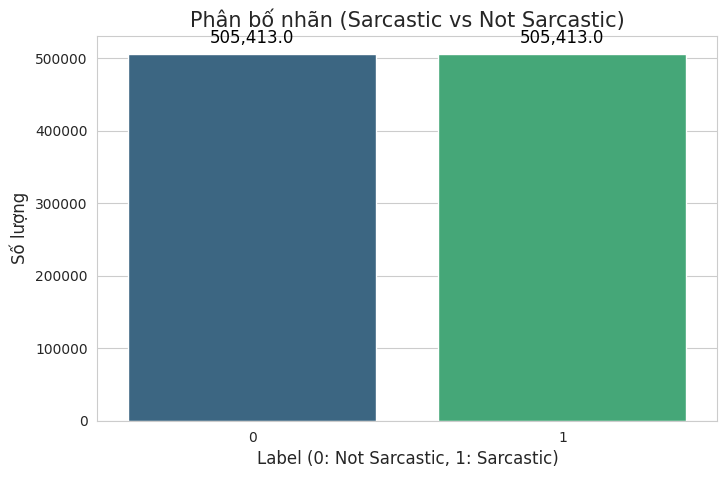

Đang tính toán độ dài văn bản...


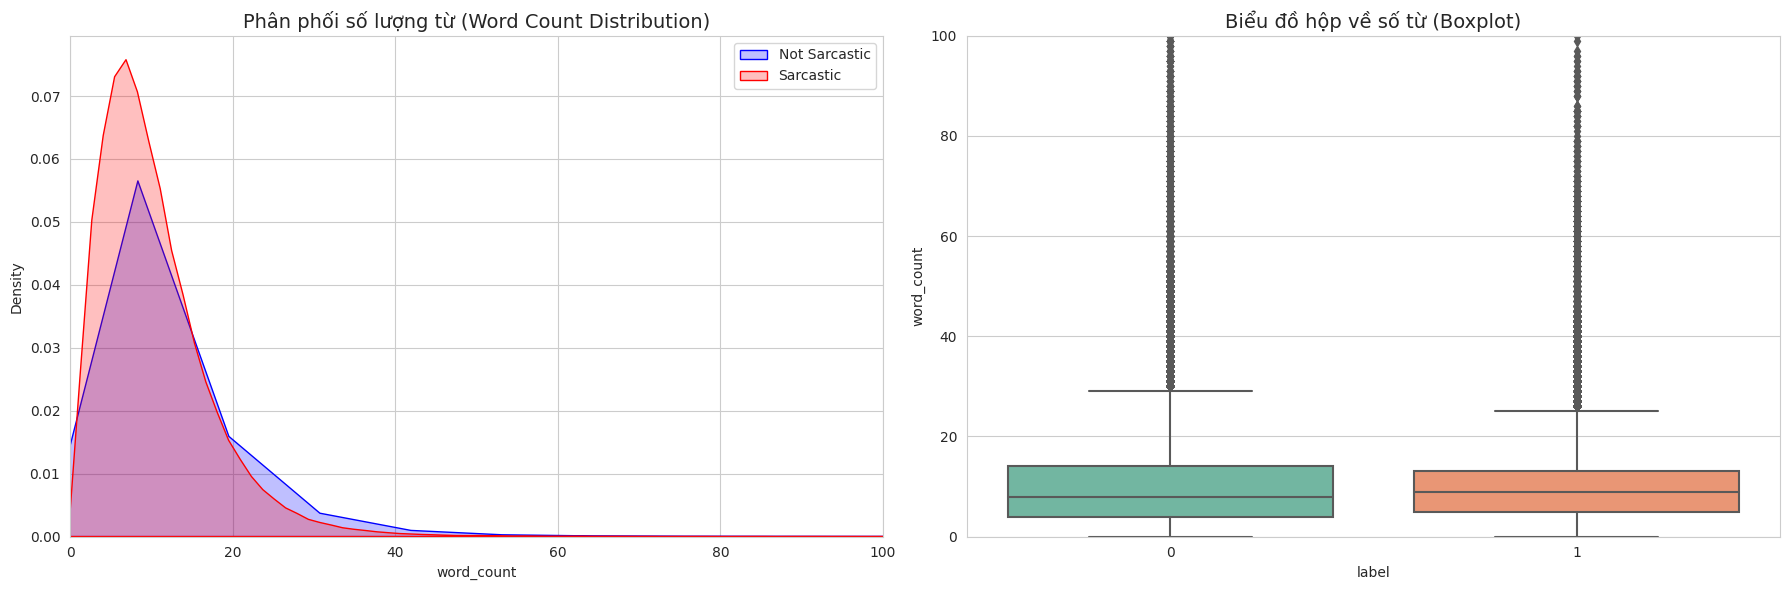

Đang vẽ WordCloud


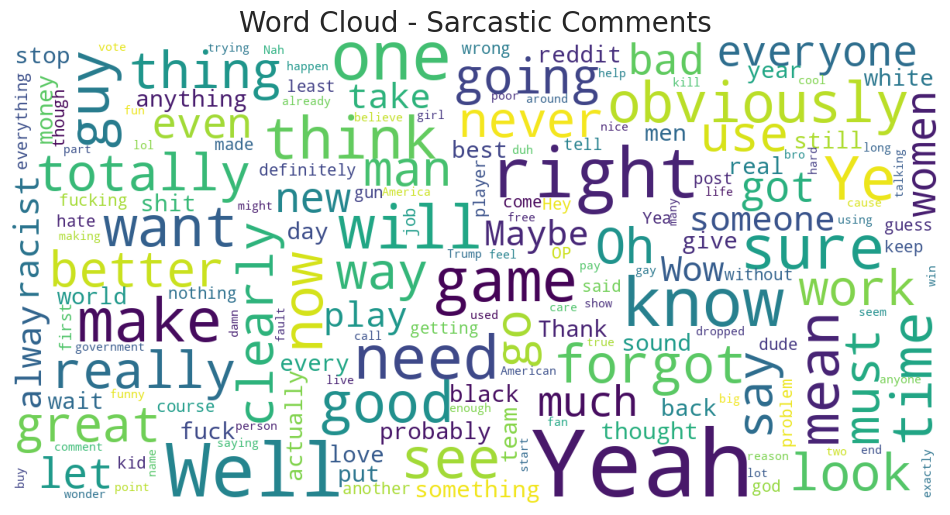

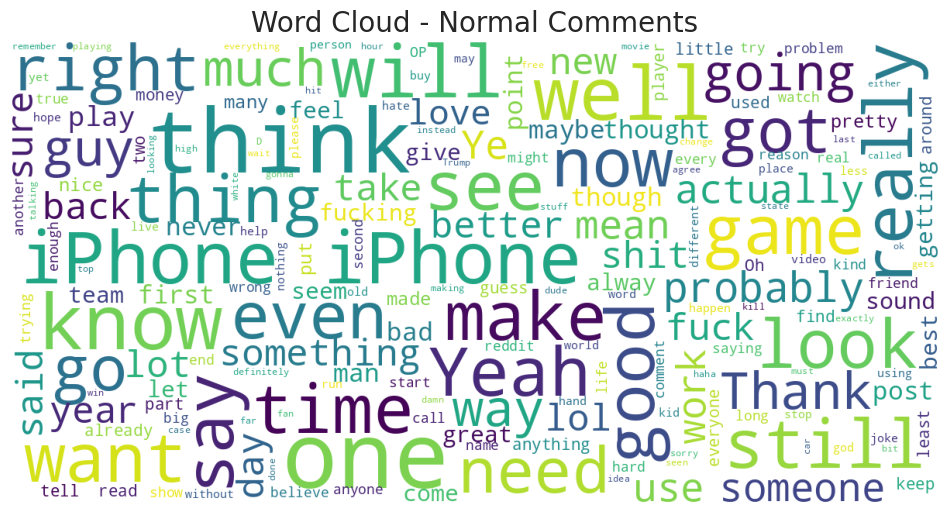

Đang phân tích Sentiment (TextBlob)...


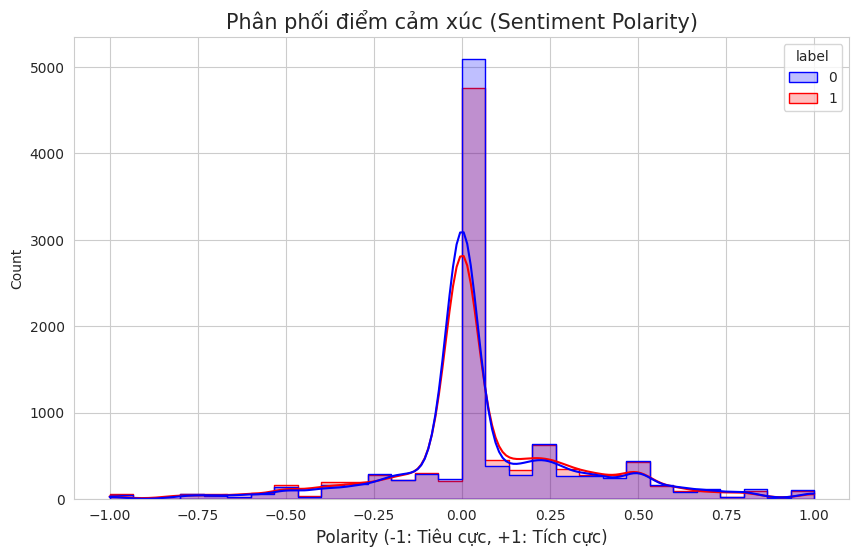


Nhận xét nhanh về Sentiment:
         count      mean       std  min  25%  50%   75%  max
label                                                       
0      10023.0  0.066758  0.283762 -1.0  0.0  0.0  0.18  1.0
1       9977.0  0.062539  0.291354 -1.0  0.0  0.0  0.20  1.0
Đang tìm Top Bigrams...


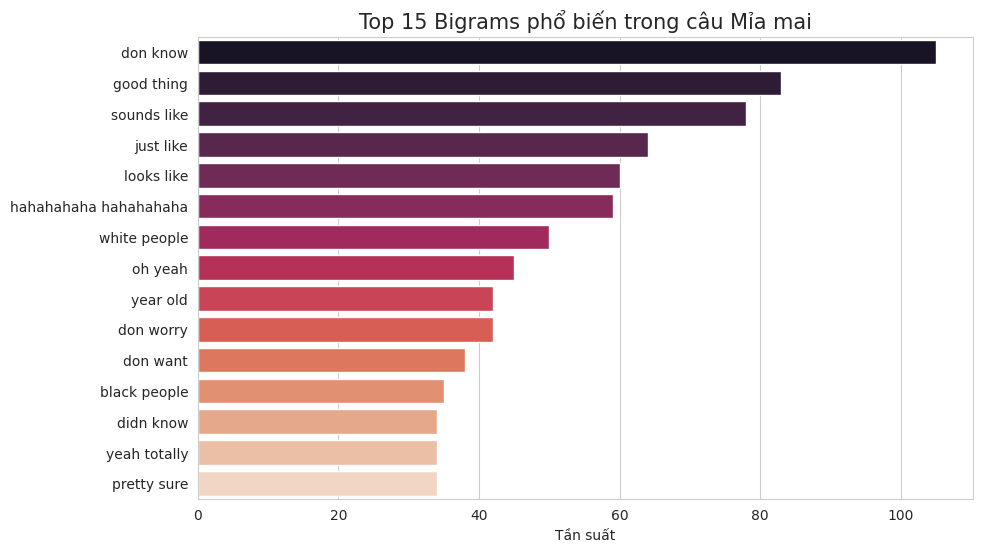

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# LOAD DỮ LIỆU
FILE_PATH = "/kaggle/input/cs213data/sarcasm.csv" 

print("Đang đọc dữ liệu (1 triệu dòng)...")
df = pd.read_csv(FILE_PATH)

print(f"Kích thước dữ liệu: {df.shape}")
print("-" * 30)
print(df.info())

# PHÂN BỐ NHÃN (CLASS BALANCE)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette='viridis')

# Thêm số lượng lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title("Phân bố nhãn (Sarcastic vs Not Sarcastic)", fontsize=15)
plt.xlabel("Label (0: Not Sarcastic, 1: Sarcastic)", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)
plt.show()

# THỐNG KÊ ĐỘ DÀI VĂN BẢN
print("Đang tính toán độ dài văn bản...")
# Tính số từ
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
# Tính số ký tự
df['char_count'] = df['comment'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ mật độ số từ
sns.kdeplot(df[df['label']==0]['word_count'], shade=True, color='blue', label='Not Sarcastic', ax=axes[0])
sns.kdeplot(df[df['label']==1]['word_count'], shade=True, color='red', label='Sarcastic', ax=axes[0])
axes[0].set_title('Phân phối số lượng từ (Word Count Distribution)', fontsize=14)
axes[0].set_xlim(0, 100) # Giới hạn nhìn cho rõ (vì có vài comment rất dài)
axes[0].legend()

# Biểu đồ Boxplot số từ (để xem outlier)
sns.boxplot(x='label', y='word_count', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Biểu đồ hộp về số từ (Boxplot)', fontsize=14)
axes[1].set_ylim(0, 100) # Zoom vào vùng dữ liệu chính

plt.tight_layout()
plt.show()

# WORD CLOUD (TỪ KHÓA PHỔ BIẾN)
print("Đang vẽ WordCloud")

stopwords = set(STOPWORDS)
# Thêm một số từ rác nếu cần
stopwords.update(["im", "dont", "cant", "us", "people"]) 

def plot_wordcloud(text, title):
    wc = WordCloud(background_color='white', stopwords=stopwords, max_words=200, max_font_size=40, scale=3, random_state=1).generate(str(text))
    plt.figure(figsize=(12, 12))
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.imshow(wc)
    plt.show()

# Lấy mẫu 100k dòng mỗi loại để vẽ cho nhanh (vẽ cả 1 triệu dòng rất lâu)
sarcastic_text = " ".join(df[df['label'] == 1]['comment'].sample(frac=0.1, random_state=42).tolist())
not_sarcastic_text = " ".join(df[df['label'] == 0]['comment'].sample(frac=0.1, random_state=42).tolist())

plot_wordcloud(sarcastic_text, "Word Cloud - Sarcastic Comments")
plot_wordcloud(not_sarcastic_text, "Word Cloud - Normal Comments")

# PHÂN TÍCH SENTIMENT (CẢM XÚC)
print("Đang phân tích Sentiment (TextBlob)...")
# Lấy mẫu 20k dòng để tính sentiment demo cho nhanh (vì bạn đã tính full lúc train rồi)
df_sample = df.sample(20000, random_state=42).copy()
df_sample['polarity'] = df_sample['comment'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(10, 6))
sns.histplot(data=df_sample, x='polarity', hue='label', kde=True, element="step", palette=['blue', 'red'], bins=30)
plt.title("Phân phối điểm cảm xúc (Sentiment Polarity)", fontsize=15)
plt.xlabel("Polarity (-1: Tiêu cực, +1: Tích cực)", fontsize=12)
plt.show()

print("\nNhận xét nhanh về Sentiment:")
print(df_sample.groupby('label')['polarity'].describe())

# 6. TOP N-GRAMS (CỤM TỪ PHỔ BIẾN)
def get_top_ngrams(corpus, n=None, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Lấy top Bigrams (2 từ)
print("Đang tìm Top Bigrams...")
sample_sarcastic = df[df['label']==1]['comment'].sample(20000, random_state=42).fillna("")
top_bigrams = get_top_ngrams(sample_sarcastic, n=2, top_k=15)

x, y = map(list, zip(*top_bigrams))
plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x, palette='rocket')
plt.title("Top 15 Bigrams phổ biến trong câu Mỉa mai", fontsize=15)
plt.xlabel("Tần suất")
plt.show()

In [16]:
import pandas as pd
file_path = "/kaggle/input/cs213data/sarcasm.csv" 
df = pd.read_csv(file_path)
random_samples = df[cols_to_show].sample(70)

for index, row in random_samples.iterrows():
    print(f"\n[Mẫu #{index}]")
    print(f"Label: {row['label']}")
    print(f"Parent: {row['parent_comment']}")
    print(f"Comment: {row['comment']}")


[Mẫu #386029]
Label: 0
Parent: Didn't know there were so many scouts in this subreddit.
Comment: Seriously, is this Facebook?

[Mẫu #270935]
Label: 0
Parent: Where will we put the Norman Powell one though?
Comment: on the moon

[Mẫu #546942]
Label: 1
Parent: The paper that uncovered phone hacking, liaised with Snowden, took on Murdoch, protested Iraq, etc. seems biased to you? Ha maybe it's *your* bias that needs re-examining, if an empirical report by a well-respected broadsheet seems biased you. Plus this article is merely citing a UN report here. But let me guess, the UN is biased as well?
Comment: The UN, The Red Cross, Amnesty International, Human Rights Watch - all just biased.

[Mẫu #88971]
Label: 1
Parent: 2016 resisting to end
Comment: How far down do I need to scroll before it's the Jews fault

[Mẫu #76831]
Label: 0
Parent: What will you never understand?
Comment: Russian

[Mẫu #399563]
Label: 1
Parent: I think you're getting confused with in the night garden.
Comment: I dro

In [12]:
import pandas as pd
file_path = "/kaggle/input/cs213data/sarcasm.csv" 
df = pd.read_csv(file_path)
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"Các cột: {list(df.columns)}")

Số dòng: 1010826
Số cột: 10
Các cột: ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']


In [13]:
columns_to_show = ['label', 'comment', 'author', 'subreddit', 'score', 'ups']
print(df[columns_to_show].head(10))

   label                                            comment       author           subreddit  score  ups
0      0                                         NC and NH.    Trumpbart            politics      2   -1
1      0  You do know west teams play against west teams...    Shbshb906                 nba     -4   -1
2      0  They were underdogs earlier today, but since G...     Creepeth                 nfl      3    3
3      0  This meme isn't funny none of the "new york ni...    icebrotha  BlackPeopleTwitter     -8   -1
4      0                    I could use one of those tools.    cush2push  MaddenUltimateTeam      6   -1
5      0  I don't pay attention to her, but as long as s...  only7inches           AskReddit      0    0
6      0      Trick or treating in general is just weird...  only7inches           AskReddit      1   -1
7      0                    Blade Mastery+Masamune or GTFO!    P0k3rm4s7       FFBraveExvius      2   -1
8      0  You don't have to, you have a good build, buy

In [14]:
columns_to_show = ['downs', 'date', 'created_utc', 'parent_comment']
print(df[columns_to_show].head(10))

   downs     date          created_utc                                     parent_comment
0     -1  2016-10  2016-10-16 23:55:23  Yeah, I get that argument. At this point, I'd ...
1     -1  2016-11  2016-11-01 00:24:10  The blazers and Mavericks (The wests 5 and 6 s...
2      0  2016-09  2016-09-22 21:45:37                            They're favored to win.
3     -1  2016-10  2016-10-18 21:03:47                         deadass don't kill my buzz
4     -1  2016-12  2016-12-30 17:00:13  Yep can confirm I saw the tool they use for th...
5      0  2016-09  2016-09-02 10:35:08                   do you find ariana grande sexy ?
6     -1  2016-10  2016-10-23 21:43:03  What's your weird or unsettling Trick or Treat...
7     -1  2016-10  2016-10-13 21:13:55  Probably Sephiroth. I refuse to taint his grea...
8     -1  2016-10  2016-10-27 19:11:06  What to upgrade? I have $500 to spend (mainly ...
9     -1  2016-11  2016-11-21 23:39:12  Probably count Kanye out Since the rest of his...


In [19]:
columns_to_show = ['label', 'comment', 'parent_comment']
print(df[columns_to_show].head(10))

   label                                            comment                                     parent_comment
0      0                                         NC and NH.  Yeah, I get that argument. At this point, I'd ...
1      0  You do know west teams play against west teams...  The blazers and Mavericks (The wests 5 and 6 s...
2      0  They were underdogs earlier today, but since G...                            They're favored to win.
3      0  This meme isn't funny none of the "new york ni...                         deadass don't kill my buzz
4      0                    I could use one of those tools.  Yep can confirm I saw the tool they use for th...
5      0  I don't pay attention to her, but as long as s...                   do you find ariana grande sexy ?
6      0      Trick or treating in general is just weird...  What's your weird or unsettling Trick or Treat...
7      0                    Blade Mastery+Masamune or GTFO!  Probably Sephiroth. I refuse to taint his grea...
8

In [6]:
import torch
from transformers import DistilBertTokenizer
from textblob import TextBlob
import pandas as pd

# 1. KHỞI TẠO CÔNG CỤ
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Mẫu dữ liệu demo (Lấy từ SARC)
sample = {
    "id": "149040",
    "parent": "And      the local official is a dem. When it comes to politics, never take things at face value.",
    "comment": "But since      when have Democrats ever been dishonest?"
}

def clean_text(text):
    """Hàm làm sạch đơn giản: Xóa khoảng trắng thừa"""
    return " ".join(text.split())

def show_full_preprocessing_pipeline(data):
    print(f"\n{'='*30} QUY TRÌNH XỬ LÝ DỮ LIỆU {'='*30}")
    print(f"📌 ID Mẫu: {data['id']}")
    
    # ---------------------------------------------------------
    # BƯỚC 1: CLEANING (LÀM SẠCH)
    # ---------------------------------------------------------
    print(f"\n{'='*10} BƯỚC 1: CLEANING (LÀM SẠCH VĂN BẢN) {'='*10}")
    raw_p = data['parent']
    raw_c = data['comment']
    
    clean_p = clean_text(raw_p)
    clean_c = clean_text(raw_c)
    
    print(f"🔴 [Raw Parent]:  '{raw_p}'")
    print(f"🟢 [Clean Parent]:'{clean_p}' (Đã xóa khoảng trắng thừa)")
    print(f"🔴 [Raw Reply]:   '{raw_c}'")
    print(f"🟢 [Clean Reply]: '{clean_c}'")

    # ---------------------------------------------------------
    # BƯỚC 2: TOKENIZATION & ENCODING (MÃ HÓA)
    # ---------------------------------------------------------
    print(f"\n{'='*10} BƯỚC 2: TOKENIZATION (MÃ HÓA BERT) {'='*10}")
    
    # Tokenize
    inputs_c = tokenizer(clean_c, max_length=128, truncation=True, padding='max_length', return_tensors='pt')
    inputs_p = tokenizer(clean_p, max_length=128, truncation=True, padding='max_length', return_tensors='pt')
    
    # Hiển thị chi tiết Token
    tokens_c = tokenizer.convert_ids_to_tokens(inputs_c['input_ids'][0])
    print(f"\n🔍 Chi tiết Token hóa câu Comment:")
    print(f"   tokens: {tokens_c}")
    print(f"   input_ids: {inputs_c['input_ids'][0].tolist()}")
    print(f"   attention_mask: {inputs_c['attention_mask'][0].tolist()}")
    print(f"   --> Ý nghĩa: [CLS] mở đầu, [SEP] kết thúc, [PAD] là phần đệm cho đủ chiều dài.")
    # Hiển thị chi tiết Token
    tokens_p = tokenizer.convert_ids_to_tokens(inputs_p['input_ids'][0])
    print(f"\n🔍 Chi tiết Token hóa câu Parent_comment:")
    print(f"   tokens: {tokens_p}")
    print(f"   input_ids: {inputs_p['input_ids'][0].tolist()}")
    print(f"   attention_mask: {inputs_p['attention_mask'][0].tolist()}")
    print(f"   --> Ý nghĩa: [CLS] mở đầu, [SEP] kết thúc, [PAD] là phần đệm cho đủ chiều dài.")
    # ---------------------------------------------------------
    # BƯỚC 3: SENTIMENT EXTRACTION (TRÍCH XUẤT CẢM XÚC - CHO LEVEL 3)
    # ---------------------------------------------------------
    print(f"\n{'='*10} BƯỚC 3: SENTIMENT ANALYSIS (TEXTBLOB) {'='*10}")
    blob_c = TextBlob(clean_c)
    blob_p = TextBlob(clean_p)
    
    sent_c = blob_c.sentiment.polarity
    sent_p = blob_p.sentiment.polarity
    sent_diff = sent_c - sent_p
    
    print(f"   Sentiment Reply ({clean_c[:15]}...): {sent_c:.4f}")
    print(f"   Sentiment Parent ({clean_p[:15]}...): {sent_p:.4f}")
    print(f"   --> Diff (Reply - Parent): {sent_diff:.4f}")

    # ---------------------------------------------------------
    # BƯỚC 4: INPUT PREPARATION FOR EACH MODEL (CHUẨN BỊ ĐẦU VÀO)
    # ---------------------------------------------------------
    print(f"\n{'='*10} BƯỚC 4: ĐÓNG GÓI DỮ LIỆU VÀO MODEL {'='*10}")
    
    # --- LEVEL 1 ---
    print(f"\n🤖 MODEL LEVEL 1 (DistilBertBaseline):")
    print("   Input: Chỉ nhận Reply.")
    print(f"   Forward(input_ids={inputs_c['input_ids'].shape}, attention_mask={inputs_c['attention_mask'].shape})")
    print("   --> Mô hình chỉ nhìn thấy: 'But since when have Democrats...'")

    # --- LEVEL 2 ---
    print(f"\n🤖 MODEL LEVEL 2 (DualDistilBert):")
    print("   Input: Nhận cả Reply và Parent (2 luồng riêng).")
    print(f"   Forward(input_ids_c={inputs_c['input_ids'].shape}, input_ids_p={inputs_p['input_ids'].shape})")
    print("   --> Luồng 1 xử lý Reply. Luồng 2 xử lý Parent. Sau đó nối lại (Concat).")

    # --- LEVEL 3 ---
    print(f"\n🤖 MODEL LEVEL 3 (DualDistilBertWithSentiment):")
    print("   Input: Reply + Parent + 3 chỉ số cảm xúc.")
    print(f"   Forward(Tensor Text + Tensor Sentiment: [{sent_c:.2f}, {sent_p:.2f}, {sent_diff:.2f}])")
    print("   --> Vector đặc trưng cuối cùng sẽ dài hơn Level 2 (cộng thêm 3 chiều).")

# Chạy Demo
show_full_preprocessing_pipeline(sample)


============================== QUY TRÌNH XỬ LÝ DỮ LIỆU ==============================
📌 ID Mẫu: 149040

========== BƯỚC 1: CLEANING (LÀM SẠCH VĂN BẢN) ==========
🔴 [Raw Parent]:  'And      the local official is a dem. When it comes to politics, never take things at face value.'
🟢 [Clean Parent]:'And the local official is a dem. When it comes to politics, never take things at face value.' (Đã xóa khoảng trắng thừa)
🔴 [Raw Reply]:   'But since      when have Democrats ever been dishonest?'
🟢 [Clean Reply]: 'But since when have Democrats ever been dishonest?'

========== BƯỚC 2: TOKENIZATION (MÃ HÓA BERT) ==========

🔍 Chi tiết Token hóa câu Comment:
   tokens: ['[CLS]', 'but', 'since', 'when', 'have', 'democrats', 'ever', 'been', 'dish', '##ones', '##t', '?', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]

In [7]:
from textblob import TextBlob

# 1. Câu Parent
parent_text = "And the local official is a dem. When it comes to politics, never take things at face value."
blob_p = TextBlob(parent_text)
print(f"🔴 Parent Assessment: {blob_p.sentiment_assessments.assessments}")
print(f"   -> Score: {blob_p.sentiment.polarity}")

# 2. Câu Comment
comment_text = "But since when have Democrats ever been dishonest?"
blob_c = TextBlob(comment_text)
print(f"\n🟢 Comment Assessment: {blob_c.sentiment_assessments.assessments}")
print(f"   -> Score: {blob_c.sentiment.polarity}")

🔴 Parent Assessment: [(['local'], 0.0, 0.0, None)]
   -> Score: 0.0

🟢 Comment Assessment: [(['dishonest'], -0.3, 0.5, None)]
   -> Score: -0.3


1. Độ dài ngắn nhất (Min Length): 1 từ
2. Độ dài dài nhất (Max Length):  2222 từ
3. Độ dài trung bình (Average):   10.46 từ
4. Trung vị (Median):             9.0 từ
5. Kích thước từ vựng (Unique words): 497257 từ
6. Tỷ lệ mẫu có độ dài <= 128: 99.99%
----------------------------------------


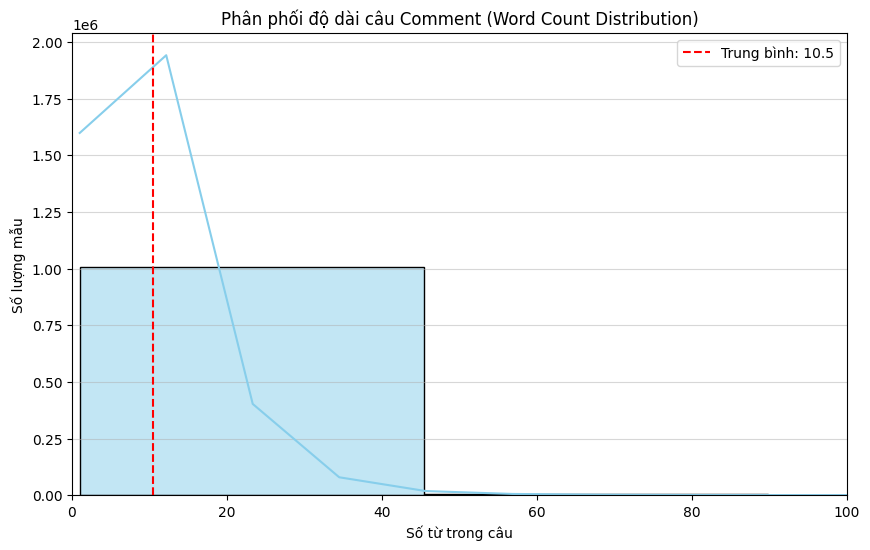

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df['length'] = df['comment'].astype(str).apply(lambda x: len(x.split()))

# 2. Tính các chỉ số thống kê
min_len = df['length'].min()
max_len = df['length'].max()
avg_len = df['length'].mean()
median_len = df['length'].median()

print(f"1. Độ dài ngắn nhất (Min Length): {min_len} từ")
print(f"2. Độ dài dài nhất (Max Length):  {max_len} từ")
print(f"3. Độ dài trung bình (Average):   {avg_len:.2f} từ")
print(f"4. Trung vị (Median):             {median_len} từ")

# 3. Tính số lượng từ vựng (Vocabulary Size)
all_words = ' '.join(df['comment'].astype(str)).split()
vocab_size = len(set(all_words))
print(f"5. Kích thước từ vựng (Unique words): {vocab_size} từ")

# 4. Kiểm tra độ bao phủ của ngưỡng 128
coverage = len(df[df['length'] <= 128]) / len(df) * 100
print(f"6. Tỷ lệ mẫu có độ dài <= 128: {coverage:.2f}%")
print("-" * 40)

plt.figure(figsize=(10, 6))
sns.histplot(df['length'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối độ dài câu Comment (Word Count Distribution)')
plt.xlabel('Số từ trong câu')
plt.ylabel('Số lượng mẫu')
plt.xlim(0, 100) # Zoom vào khoảng 0-100 vì đa số comment ngắn
plt.axvline(x=avg_len, color='red', linestyle='--', label=f'Trung bình: {avg_len:.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()